# Multiclass Support Vector Machine exercise

*Complete and hand in this completed worksheet (including its outputs and any supporting code outside of the worksheet) with your assignment submission. For more details see the [assignments page](http://vision.stanford.edu/teaching/cs231n/assignments.html) on the course website.*

In this exercise you will:
    
- implement a fully-vectorized **loss function** for the SVM
- implement the fully-vectorized expression for its **analytic gradient**
- **check your implementation** using numerical gradient
- use a validation set to **tune the learning rate and regularization** strength
- **optimize** the loss function with **SGD**
- **visualize** the final learned weights


In [1]:
# Run some setup code for this notebook.
import random
import numpy as np
from cs231n.data_utils import load_CIFAR10
import matplotlib.pyplot as plt

# This is a bit of magic to make matplotlib figures appear inline in the
# notebook rather than in a new window.
%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

# Some more magic so that the notebook will reload external python modules;
# see http://stackoverflow.com/questions/1907993/autoreload-of-modules-in-ipython
%load_ext autoreload
%autoreload 2

## CIFAR-10 Data Loading and Preprocessing

In [2]:
# Load the raw CIFAR-10 data.
cifar10_dir = 'cs231n/cifar-10-batches-py'

# Cleaning up variables to prevent loading data multiple times (which may cause memory issue)
try:
   del X_train, y_train
   del X_test, y_test
   print('Clear previously loaded data.')
except:
   pass

X_train, y_train, X_test, y_test = load_CIFAR10(cifar10_dir)

# As a sanity check, we print out the size of the training and test data.
print('Training data shape: ', X_train.shape)
print('Training labels shape: ', y_train.shape)
print('Test data shape: ', X_test.shape)
print('Test labels shape: ', y_test.shape)

Training data shape:  (50000, 32, 32, 3)
Training labels shape:  (50000,)
Test data shape:  (10000, 32, 32, 3)
Test labels shape:  (10000,)


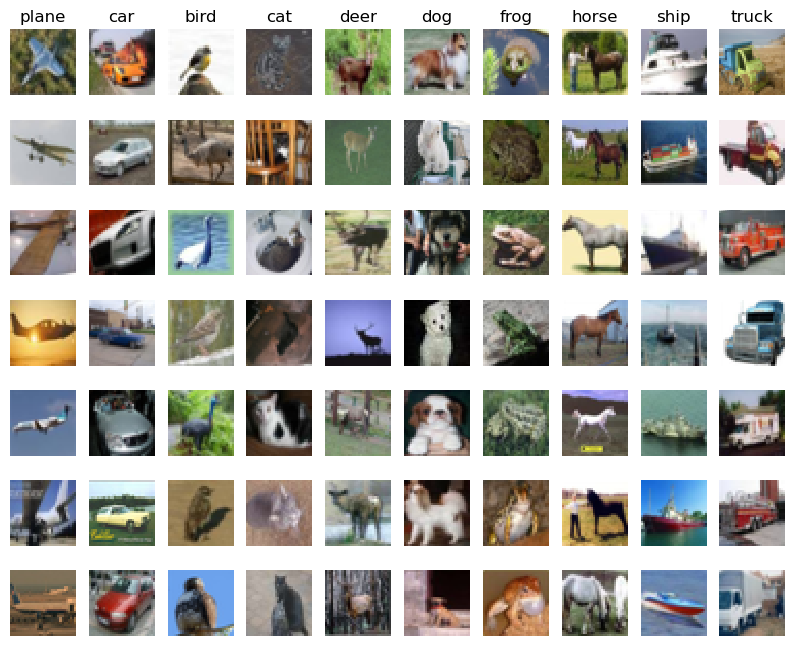

In [3]:
# Visualize some examples from the dataset.
# We show a few examples of training images from each class.
classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
num_classes = len(classes)
samples_per_class = 7
for y, cls in enumerate(classes):
    idxs = np.flatnonzero(y_train == y)
    idxs = np.random.choice(idxs, samples_per_class, replace=False)
    for i, idx in enumerate(idxs):
        plt_idx = i * num_classes + y + 1
        plt.subplot(samples_per_class, num_classes, plt_idx)
        plt.imshow(X_train[idx].astype('uint8'))
        plt.axis('off')
        if i == 0:
            plt.title(cls)
plt.show()

In [4]:
# Split the data into train, val, and test sets. In addition we will
# create a small development set as a subset of the training data;
# we can use this for development so our code runs faster.
num_training = 49000
num_validation = 1000
num_test = 1000
num_dev = 500

# Our validation set will be num_validation points from the original
# training set.
mask = range(num_training, num_training + num_validation)
X_val = X_train[mask]
y_val = y_train[mask]

# Our training set will be the first num_train points from the original
# training set.
mask = range(num_training)
X_train = X_train[mask]
y_train = y_train[mask]

# We will also make a development set, which is a small subset of
# the training set.
mask = np.random.choice(num_training, num_dev, replace=False)
X_dev = X_train[mask]
y_dev = y_train[mask]

# We use the first num_test points of the original test set as our
# test set.
mask = range(num_test)
X_test = X_test[mask]
y_test = y_test[mask]

print('Train data shape: ', X_train.shape)
print('Train labels shape: ', y_train.shape)
print('Validation data shape: ', X_val.shape)
print('Validation labels shape: ', y_val.shape)
print('Test data shape: ', X_test.shape)
print('Test labels shape: ', y_test.shape)

Train data shape:  (49000, 32, 32, 3)
Train labels shape:  (49000,)
Validation data shape:  (1000, 32, 32, 3)
Validation labels shape:  (1000,)
Test data shape:  (1000, 32, 32, 3)
Test labels shape:  (1000,)


In [5]:
# Preprocessing: reshape the image data into rows
X_train = np.reshape(X_train, (X_train.shape[0], -1))
X_val = np.reshape(X_val, (X_val.shape[0], -1))
X_test = np.reshape(X_test, (X_test.shape[0], -1))
X_dev = np.reshape(X_dev, (X_dev.shape[0], -1))

# As a sanity check, print out the shapes of the data
print('Training data shape: ', X_train.shape)
print('Validation data shape: ', X_val.shape)
print('Test data shape: ', X_test.shape)
print('dev data shape: ', X_dev.shape)

Training data shape:  (49000, 3072)
Validation data shape:  (1000, 3072)
Test data shape:  (1000, 3072)
dev data shape:  (500, 3072)


[130.64189796 135.98173469 132.47391837 130.05569388 135.34804082
 131.75402041 130.96055102 136.14328571 132.47636735 131.48467347]


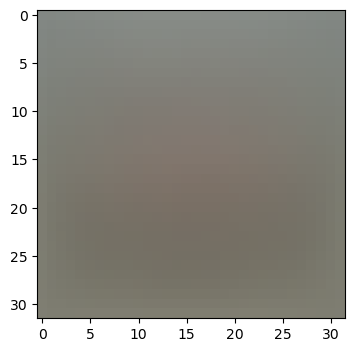

(49000, 3073) (1000, 3073) (1000, 3073) (500, 3073)


In [6]:
# Preprocessing: subtract the mean image
# first: compute the image mean based on the training data
mean_image = np.mean(X_train, axis=0)
print(mean_image[:10]) # print a few of the elements
plt.figure(figsize=(4,4))
plt.imshow(mean_image.reshape((32,32,3)).astype('uint8')) # visualize the mean image
plt.show()

# second: subtract the mean image from train and test data
X_train -= mean_image
X_val -= mean_image
X_test -= mean_image
X_dev -= mean_image

# third: append the bias dimension of ones (i.e. bias trick) so that our SVM
# only has to worry about optimizing a single weight matrix W.
X_train = np.hstack([X_train, np.ones((X_train.shape[0], 1))])
X_val = np.hstack([X_val, np.ones((X_val.shape[0], 1))])
X_test = np.hstack([X_test, np.ones((X_test.shape[0], 1))])
X_dev = np.hstack([X_dev, np.ones((X_dev.shape[0], 1))])

print(X_train.shape, X_val.shape, X_test.shape, X_dev.shape)

## SVM Classifier

Your code for this section will all be written inside **cs231n/classifiers/linear_svm.py**. 

As you can see, we have prefilled the function `compute_loss_naive` which uses for loops to evaluate the multiclass SVM loss function. 

In [7]:
# Evaluate the naive implementation of the loss we provided for you:
from cs231n.classifiers.linear_svm import svm_loss_naive
import time

# generate a random SVM weight matrix of small numbers
W = np.random.randn(3073, 10) * 0.0001 

loss, grad = svm_loss_naive(W, X_dev, y_dev, 0.000005)
print('loss: %f' % (loss, ))

loss: 9.061640


The `grad` returned from the function above is right now all zero. Derive and implement the gradient for the SVM cost function and implement it inline inside the function `svm_loss_naive`. You will find it helpful to interleave your new code inside the existing function.

To check that you have correctly implemented the gradient correctly, you can numerically estimate the gradient of the loss function and compare the numeric estimate to the gradient that you computed. We have provided code that does this for you:

In [8]:
# Once you've implemented the gradient, recompute it with the code below
# and gradient check it with the function we provided for you

# Compute the loss and its gradient at W.
loss, grad = svm_loss_naive(W, X_dev, y_dev, 0.0)

# Numerically compute the gradient along several randomly chosen dimensions, and
# compare them with your analytically computed gradient. The numbers should match
# almost exactly along all dimensions.
from cs231n.gradient_check import grad_check_sparse
f = lambda w: svm_loss_naive(w, X_dev, y_dev, 0.0)[0]
grad_numerical = grad_check_sparse(f, W, grad)

# do the gradient check once again with regularization turned on
# you didn't forget the regularization gradient did you?
loss, grad = svm_loss_naive(W, X_dev, y_dev, 5e1)
f = lambda w: svm_loss_naive(w, X_dev, y_dev, 5e1)[0]
grad_numerical = grad_check_sparse(f, W, grad)

numerical: 1.274022 analytic: 1.274022, relative error: 2.821241e-10
numerical: 2.011059 analytic: 2.011059, relative error: 5.906048e-11
numerical: 0.667890 analytic: 0.667890, relative error: 3.497608e-10
numerical: 2.820147 analytic: 2.820147, relative error: 3.617808e-11
numerical: -48.929541 analytic: -48.929541, relative error: 3.765418e-12
numerical: -0.271166 analytic: -0.235838, relative error: 6.968098e-02
numerical: -8.206503 analytic: -8.206503, relative error: 9.408638e-12
numerical: -3.818412 analytic: -3.818412, relative error: 2.835962e-11
numerical: 22.136441 analytic: 22.136441, relative error: 6.234779e-12
numerical: -2.877264 analytic: -2.874807, relative error: 4.270801e-04
numerical: 2.516187 analytic: 2.516187, relative error: 1.734143e-10
numerical: 13.798268 analytic: 13.798268, relative error: 1.921416e-11
numerical: -5.465030 analytic: -5.465030, relative error: 7.343074e-12
numerical: -0.067049 analytic: 0.036200, relative error: 1.000000e+00
numerical: -5.8

**Inline Question 1**

It is possible that once in a while a dimension in the gradcheck will not match exactly. What could such a discrepancy be caused by? Is it a reason for concern? What is a simple example in one dimension where a gradient check could fail? How would change the margin affect of the frequency of this happening? *Hint: the SVM loss function is not strictly speaking differentiable*

$\color{blue}{\textit Your Answer:}$ 

**原因**：SVM损失函数在margin=0的点**不可微**（不可导）。SVM损失函数使用hinge loss：$L_i = \sum_{j \neq y_i} \max(0, s_j - s_{y_i} + \Delta)$，其中$\max(0, x)$函数在$x=0$处不可微。

当margin恰好等于0时（即$s_j - s_{y_i} + \Delta = 0$），损失函数从0变为正数，这个转折点不可微：
- 当margin < 0时，$\max(0, margin) = 0$，梯度为0
- 当margin > 0时，$\max(0, margin) = margin$，梯度为1
- 当margin = 0时，左导数为0，右导数为1，不相等，因此不可微

**是否值得担心**：通常**不需要担心**，只要数值梯度和解析梯度的误差在合理范围内（如$10^{-6}$或$10^{-7}$），就可以认为实现是正确的。这种不匹配是数学上的必然结果，不是实现错误。

**一维例子**：假设有一个样本$X_i$，正确类别$y_i$的分数为$s_{y_i} = 5$，错误类别$j$的分数为$s_j = 4$，margin $\Delta = 1$。则：
- margin = $s_j - s_{y_i} + \Delta = 4 - 5 + 1 = 0$
- 在这个点，损失函数不可微：
  - 如果$s_j$稍微小于4（如3.999），margin < 0，损失为0，梯度为0
  - 如果$s_j$稍微大于4（如4.001），margin > 0，损失为正数，梯度为1
  - 数值梯度检查使用有限差分近似：$\frac{f(x+h) - f(x-h)}{2h}$，当$h$很小时，如果正好在不可微点附近，可能得到不一致的结果

**margin的影响**：如果margin（$\Delta$）**增大**，margin=0的情况会更少发生，因为需要更大的分数差异才能达到margin=0。例如：
- $\Delta = 1$：当$s_j = s_{y_i} - 1$时，margin = 0
- $\Delta = 2$：当$s_j = s_{y_i} - 2$时，margin = 0

因此，**增大margin会减少梯度检查失败的概率**，因为margin=0的边界情况更少出现。  


In [9]:
# Next implement the function svm_loss_vectorized; for now only compute the loss;
# we will implement the gradient in a moment.
tic = time.time()
loss_naive, grad_naive = svm_loss_naive(W, X_dev, y_dev, 0.000005)
toc = time.time()
print('Naive loss: %e computed in %fs' % (loss_naive, toc - tic))

from cs231n.classifiers.linear_svm import svm_loss_vectorized
tic = time.time()
loss_vectorized, _ = svm_loss_vectorized(W, X_dev, y_dev, 0.000005)
toc = time.time()
print('Vectorized loss: %e computed in %fs' % (loss_vectorized, toc - tic))

# The losses should match but your vectorized implementation should be much faster.
print('difference: %f' % (loss_naive - loss_vectorized))

Naive loss: 9.061640e+00 computed in 0.055763s
Vectorized loss: 9.061640e+00 computed in 0.002664s
difference: 0.000000


In [10]:
# Complete the implementation of svm_loss_vectorized, and compute the gradient
# of the loss function in a vectorized way.

# The naive implementation and the vectorized implementation should match, but
# the vectorized version should still be much faster.
tic = time.time()
_, grad_naive = svm_loss_naive(W, X_dev, y_dev, 0.000005)
toc = time.time()
print('Naive loss and gradient: computed in %fs' % (toc - tic))

tic = time.time()
_, grad_vectorized = svm_loss_vectorized(W, X_dev, y_dev, 0.000005)
toc = time.time()
print('Vectorized loss and gradient: computed in %fs' % (toc - tic))

# The loss is a single number, so it is easy to compare the values computed
# by the two implementations. The gradient on the other hand is a matrix, so
# we use the Frobenius norm to compare them.
difference = np.linalg.norm(grad_naive - grad_vectorized, ord='fro')
print('difference: %f' % difference)

Naive loss and gradient: computed in 0.049859s
Vectorized loss and gradient: computed in 0.003849s
difference: 0.000000


### Stochastic Gradient Descent

We now have vectorized and efficient expressions for the loss, the gradient and our gradient matches the numerical gradient. We are therefore ready to do SGD to minimize the loss.

In [11]:
# In the file linear_classifier.py, implement SGD in the function
# LinearClassifier.train() and then run it with the code below.
from cs231n.classifiers import LinearSVM
svm = LinearSVM()
tic = time.time()
loss_hist = svm.train(X_train, y_train, learning_rate=1e-7, reg=2.5e4,
                      num_iters=1500, verbose=True)
toc = time.time()
print('That took %fs' % (toc - tic))

iteration 0 / 1500: loss 796.388519
iteration 100 / 1500: loss 289.569784
iteration 200 / 1500: loss 108.658778
iteration 300 / 1500: loss 43.272068
iteration 400 / 1500: loss 18.608491
iteration 500 / 1500: loss 10.530865
iteration 600 / 1500: loss 7.185692
iteration 700 / 1500: loss 6.074623
iteration 800 / 1500: loss 5.433184
iteration 900 / 1500: loss 5.625405
iteration 1000 / 1500: loss 4.831656
iteration 1100 / 1500: loss 5.012448
iteration 1200 / 1500: loss 5.427939
iteration 1300 / 1500: loss 5.584215
iteration 1400 / 1500: loss 5.060628
That took 2.984730s


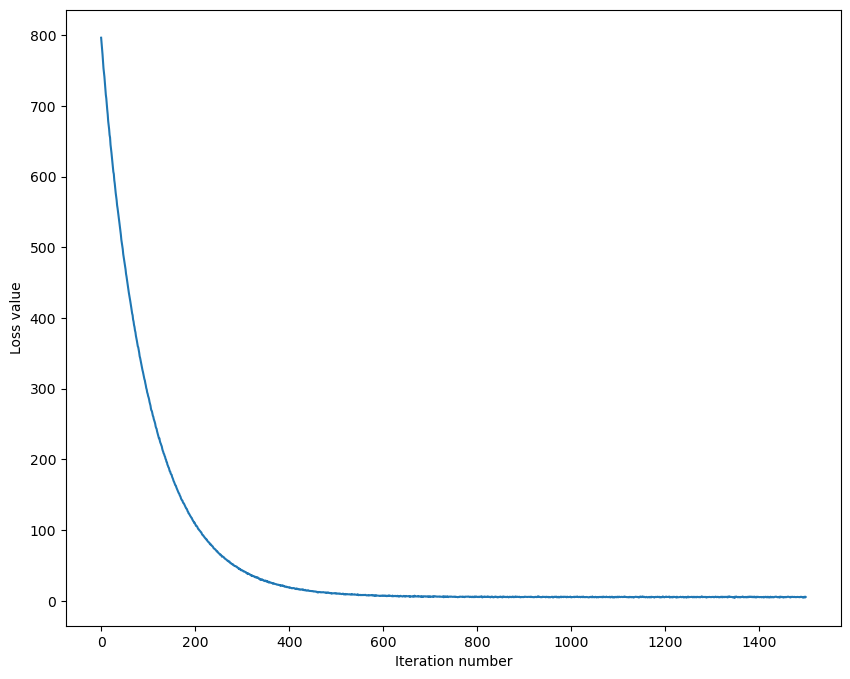

In [12]:
# A useful debugging strategy is to plot the loss as a function of
# iteration number:
plt.plot(loss_hist)
plt.xlabel('Iteration number')
plt.ylabel('Loss value')
plt.show()

In [13]:
# Write the LinearSVM.predict function and evaluate the performance on both the
# training and validation set
y_train_pred = svm.predict(X_train)
print('training accuracy: %f' % (np.mean(y_train == y_train_pred), ))
y_val_pred = svm.predict(X_val)
print('validation accuracy: %f' % (np.mean(y_val == y_val_pred), ))

training accuracy: 0.366020
validation accuracy: 0.375000


In [18]:
# Use the validation set to tune hyperparameters (regularization strength and
# learning rate). You should experiment with different ranges for the learning
# rates and regularization strengths; if you are careful you should be able to
# get a classification accuracy of about 0.39 on the validation set.

#Note: you may see runtime/overflow warnings during hyper-parameter search. 
# This may be caused by extreme values, and is not a bug.

learning_rates = [1e-7, 5e-5]
regularization_strengths = [2.5e4, 5e4]

# results is dictionary mapping tuples of the form
# (learning_rate, regularization_strength) to tuples of the form
# (training_accuracy, validation_accuracy). The accuracy is simply the fraction
# of data points that are correctly classified.
results = {}
best_val = -1   # The highest validation accuracy that we have seen so far.
best_svm = None # The LinearSVM object that achieved the highest validation rate.

################################################################################
# TODO:                                                                        #
# Write code that chooses the best hyperparameters by tuning on the validation #
# set. For each combination of hyperparameters, train a linear SVM on the      #
# training set, compute its accuracy on the training and validation sets, and  #
# store these numbers in the results dictionary. In addition, store the best   #
# validation accuracy in best_val and the LinearSVM object that achieves this  #
# accuracy in best_svm.                                                        #
#                                                                              #
# Hint: You should use a small value for num_iters as you develop your         #
# validation code so that the SVMs don't take much time to train; once you are #
# confident that your validation code works, you should rerun the validation   #
# code with a larger value for num_iters.                                      #
################################################################################
# *****START OF YOUR CODE (DO NOT DELETE/MODIFY THIS LINE)*****

for lr in learning_rates:
    for reg in regularization_strengths:
        # 训练SVM
        svm = LinearSVM()
        loss_hist = svm.train(X_train, y_train, learning_rate=lr, reg=reg,
                              num_iters=1500, verbose=False)
        
        # 预测
        y_train_pred = svm.predict(X_train)
        y_val_pred = svm.predict(X_val)
        
        # 计算准确率
        train_acc = np.mean(y_train_pred == y_train)
        val_acc = np.mean(y_val_pred == y_val)
        
        # 保存结果
        results[(lr, reg)] = (train_acc, val_acc)
        
        # 更新最佳模型
        if val_acc > best_val:
            best_val = val_acc
            best_svm = svm

# *****END OF YOUR CODE (DO NOT DELETE/MODIFY THIS LINE)*****
    
# Print out results.
for lr, reg in sorted(results):
    train_accuracy, val_accuracy = results[(lr, reg)]
    print('lr %e reg %e train accuracy: %f val accuracy: %f' % (
                lr, reg, train_accuracy, val_accuracy))
    
print('best validation accuracy achieved during cross-validation: %f' % best_val)

lr 1.000000e-07 reg 2.500000e+04 train accuracy: 0.367755 val accuracy: 0.369000
lr 1.000000e-07 reg 5.000000e+04 train accuracy: 0.365204 val accuracy: 0.367000
lr 5.000000e-05 reg 2.500000e+04 train accuracy: 0.072796 val accuracy: 0.084000
lr 5.000000e-05 reg 5.000000e+04 train accuracy: 0.100265 val accuracy: 0.087000
best validation accuracy achieved during cross-validation: 0.369000


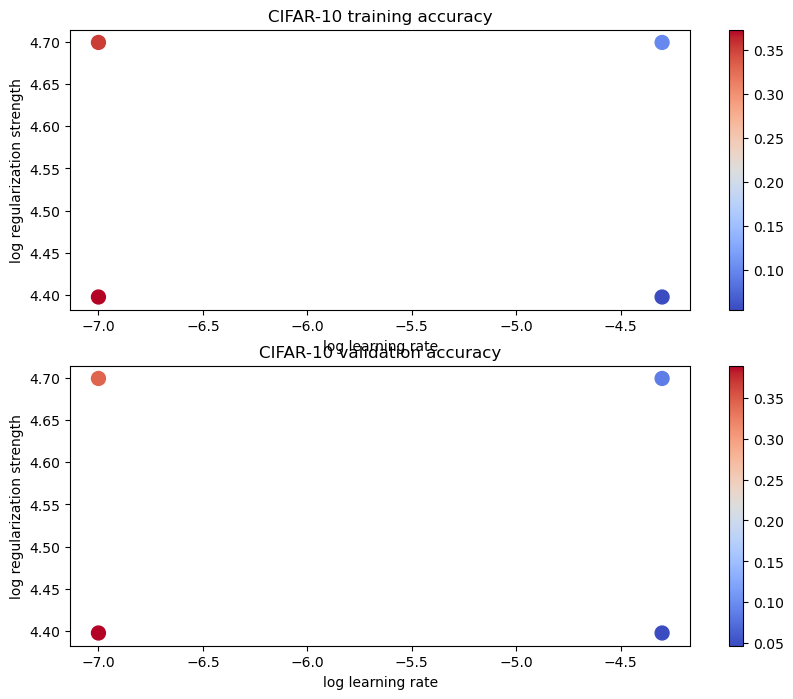

In [15]:
# Visualize the cross-validation results
import math
x_scatter = [math.log10(x[0]) for x in results]
y_scatter = [math.log10(x[1]) for x in results]

# plot training accuracy
marker_size = 100
colors = [results[x][0] for x in results]
plt.subplot(2, 1, 1)
plt.scatter(x_scatter, y_scatter, marker_size, c=colors, cmap=plt.cm.coolwarm)
plt.colorbar()
plt.xlabel('log learning rate')
plt.ylabel('log regularization strength')
plt.title('CIFAR-10 training accuracy')

# plot validation accuracy
colors = [results[x][1] for x in results] # default size of markers is 20
plt.subplot(2, 1, 2)
plt.scatter(x_scatter, y_scatter, marker_size, c=colors, cmap=plt.cm.coolwarm)
plt.colorbar()
plt.xlabel('log learning rate')
plt.ylabel('log regularization strength')
plt.title('CIFAR-10 validation accuracy')
plt.show()

In [19]:
# Evaluate the best svm on test set
y_test_pred = best_svm.predict(X_test)
test_accuracy = np.mean(y_test == y_test_pred)
print('linear SVM on raw pixels final test set accuracy: %f' % test_accuracy)

linear SVM on raw pixels final test set accuracy: 0.367000


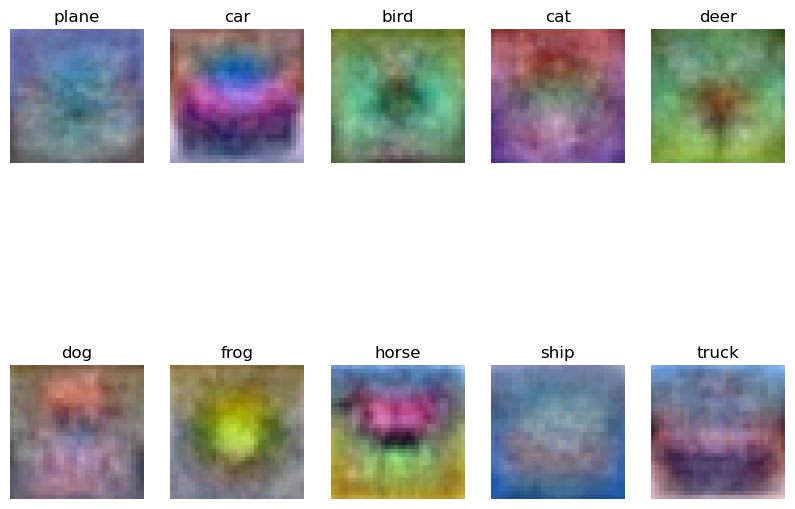

In [20]:
# Visualize the learned weights for each class.
# Depending on your choice of learning rate and regularization strength, these may
# or may not be nice to look at.
w = best_svm.W[:-1,:] # strip out the bias
w = w.reshape(32, 32, 3, 10)
w_min, w_max = np.min(w), np.max(w)
classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
for i in range(10):
    plt.subplot(2, 5, i + 1)
      
    # Rescale the weights to be between 0 and 255
    wimg = 255.0 * (w[:, :, :, i].squeeze() - w_min) / (w_max - w_min)
    plt.imshow(wimg.astype('uint8'))
    plt.axis('off')
    plt.title(classes[i])

**Inline question 2**

Describe what your visualized SVM weights look like, and offer a brief explanation for why they look they way that they do.

$\color{blue}{\textit Your Answer:}$ 

**可视化权重的外观**：每个类别的权重可视化后，看起来像是该类别的"模板"或"平均图像"。具体特征包括：

- **飞机的权重**：通常显示蓝色背景（天空）和白色/灰色机身的模糊轮廓，可能还有机翼的形状
- **汽车的权重**：显示车轮、车身的形状，可能还有道路的纹理
- **鸟的权重**：显示鸟的身体轮廓，可能包括翅膀和头部
- **猫/狗的权重**：显示动物的身体轮廓，包括头部、身体和可能的四肢
- **马的权重**：显示四条腿和身体的形状，可能还有鬃毛的轮廓
- **船的权重**：显示船体的形状，可能还有水面的纹理
- **卡车的权重**：显示大型车辆的形状，可能包括车厢和车轮

这些权重图像通常**比较模糊**，不像真实的训练图像那样清晰，但能够捕捉到每个类别的**关键视觉特征**。

**原因解释**：

1. **线性分类器的本质**：SVM是线性分类器，权重矩阵$W$的每一列对应一个类别。对于输入图像$X$，得分计算为$s = X \cdot W$。如果图像$X$与权重$W$的某个列（对应某个类别）相似，点积会很大，得分就高。因此，权重$W$的每一列可以看作是每个类别的"模板"。

2. **梯度更新的机制**：在训练过程中，SGD通过以下方式更新权重：
   - 对于**正确分类**的样本：如果margin > 0（即错误类别得分太高），权重会向正确类别的样本方向更新，远离错误类别的样本
   - 对于**错误分类**的样本：权重会远离错误预测的类别，向正确类别更新
   - 经过多次迭代，权重会收敛到能够区分不同类别的模式

3. **平均效果**：由于权重是通过对所有训练样本的梯度更新得到的，最终学到的权重反映了该类别的**平均特征**。具体来说：
   - 权重$W_j$（类别$j$的权重）会学习到类别$j$的典型特征
   - 如果某个像素位置在类别$j$的大多数图像中都是某个颜色，权重在这个位置的值会倾向于这个颜色
   - 因此，权重可视化后看起来像是该类别的"平均图像"

4. **数学解释**：权重$W$可以理解为每个类别的**原型（prototype）**。在训练过程中，损失函数鼓励：
   - 正确类别的得分高：$X_i \cdot W_{y_i}$ 大
   - 错误类别的得分低：$X_i \cdot W_j$ 小（当$j \neq y_i$时）
   
   这意味着$W_{y_i}$会学习到与类别$y_i$的样本相似的模式，而$W_j$会学习到与类别$j$的样本相似的模式。由于点积$X \cdot W$衡量的是相似性，权重自然会收敛到每个类别的典型特征。

5. **为什么看起来模糊**：
   - 权重是**所有训练样本的平均**，而不是单个样本
   - 同一类别的图像在细节上差异很大，平均后会模糊掉细节
   - 权重需要**泛化**到所有可能的图像，而不是记忆单个样本
   - 正则化项也会平滑权重，防止过拟合

**总结**：SVM权重可视化后看起来像是每个类别的"模板"或"平均图像"，这是线性分类器的本质决定的——权重需要学习每个类别的典型特征，以便通过点积计算相似性来进行分类。  
